# PrimeKG Dataset Exploratory Data Analysis

This notebook explores the local PrimeKG dataset used for the BioKG Explorer project. The goal is to understand the graph schema, node and relation distributions, feature tables, and practical constraints for building an interactive biomedical knowledge graph visualization tool.

Dataset location expected by this notebook: `../prime-kg-dataset/`.

## 1. Environment Setup

Import the core Python libraries used throughout this notebook and configure plotting defaults. The notebook intentionally uses common dependencies (`pandas`, `matplotlib`) so it can run in a lightweight local environment.

In [1]:
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Dataset Paths

Define the dataset directory and the expected PrimeKG files. This cell also verifies that the files are present before the rest of the analysis runs.

In [2]:
DATA_DIR = Path("../prime-kg-dataset").resolve()

expected_files = [
    "README.txt",
    "nodes.csv",
    "edges.csv",
    "kg.csv",
    "disease_features.csv",
    "drug_features.csv",
    "kg_raw.csv",
    "kg_giant.csv",
    "kg_grouped.csv",
    "kg_grouped_diseases.csv",
    "kg_grouped_diseases_bert_map.csv",
]

file_status = pd.DataFrame(
    {
        "file": expected_files,
        "exists": [(DATA_DIR / name).exists() for name in expected_files],
        "size_mb": [
            round((DATA_DIR / name).stat().st_size / (1024**2), 2) if (DATA_DIR / name).exists() else None
            for name in expected_files
        ],
    }
)

print(f"Dataset directory: {DATA_DIR}")
file_status

Dataset directory: /Users/faizanfaisal/Laptop_Data/Davis_Courses/ECS273_Visual_Analytics/proj/BioKG-Explorer/prime-kg-dataset


,file,exists,size_mb
0,README.txt,True,0.00
1,nodes.csv,True,7.50
2,edges.csv,True,368.67
3,kg.csv,True,936.27
4,disease_features.csv,True,107.21
5,drug_features.csv,True,9.34
6,kg_raw.csv,True,851.96
7,kg_giant.csv,True,851.94
8,kg_grouped.csv,True,847.18
9,kg_grouped_diseases.csv,True,2.59


## 3. README Notes

Read the dataset README so the analysis remains grounded in the dataset author's description of each file.

In [3]:
readme_text = (DATA_DIR / "README.txt").read_text(encoding="utf-8")
print(readme_text)

PrimeKG

Here, we present the Precision Medicine Knowledge Graph (PrimeKG). This resource provides a holistic view of diseases. We have integrated 20 high-quality datasets, biorepositories and ontologies to curate this knowledge graph. PrimeKG systematically captures information about 17,080 diseases with 4,050,249 relationships representing various major biological scales, including diseases, drugs, genes, proteins, exposures, phenotypes, drug side effects, molecular functions, cellular components, biological processes, anatomical regions, and pathways. Disease nodes in our multi-relational knowledge graph are densely connected to every other node type. PrimeKG's rich graph structure is supplemented with textual descriptions of clinical guidelines for drug and disease nodes to enable multi-modal disease exploration. For further details, please read our publication cited below. To get started with using PrimeKG, please explore the tutorial shared on our GitHub repository: https://githu

## 4. CSV Schemas and Row Counts

Inspect each CSV header and count rows. The edge-level files are large, so this uses Python's CSV reader instead of loading every file into memory with pandas.

In [4]:
import csv

def csv_header_and_rows(path: Path):
    with path.open(newline="", encoding="utf-8") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        row_count = sum(1 for _ in reader)
    return header, row_count

schema_rows = []
for name in expected_files:
    path = DATA_DIR / name
    if path.suffix == ".csv" and path.exists():
        header, row_count = csv_header_and_rows(path)
        schema_rows.append({"file": name, "rows": row_count, "columns": header})

schemas = pd.DataFrame(schema_rows).sort_values("file")
schemas

,file,rows,columns
3,disease_features.csv,44133,"[node_index, mondo_id, mondo_name, group_id_bert, group_name_bert, mondo_definition, umls_description, orphanet_defi..."
4,drug_features.csv,7957,"[node_index, description, half_life, indication, mechanism_of_action, protein_binding, pharmacodynamics, state, atc_..."
1,edges.csv,8100498,"[relation, display_relation, x_index, y_index]"
2,kg.csv,8100498,"[relation, display_relation, x_index, x_id, x_type, x_name, x_source, y_index, y_id, y_type, y_name, y_source]"
6,kg_giant.csv,8196862,"[relation, display_relation, x_id, x_type, x_name, x_source, y_id, y_type, y_name, y_source]"
7,kg_grouped.csv,8100498,"[relation, display_relation, x_id, x_type, x_name, x_source, y_id, y_type, y_name, y_source]"
8,kg_grouped_diseases.csv,22205,"[node_id, node_type, node_name, node_source, group_name_auto, group_name_bert]"
9,kg_grouped_diseases_bert_map.csv,6392,"[node_id, node_type, node_name, node_source, group_name_auto, group_name_bert, group_id_bert]"
5,kg_raw.csv,8197026,"[relation, display_relation, x_id, x_type, x_name, x_source, y_id, y_type, y_name, y_source]"
0,nodes.csv,129375,"[node_index, node_id, node_type, node_name, node_source]"


## 5. Load Core Node Table

Load `nodes.csv`, which is small enough for memory. This table is the canonical node lookup keyed by `node_index`.

In [5]:
nodes = pd.read_csv(DATA_DIR / "nodes.csv")

print(nodes.shape)
nodes.head()

(129375, 5)


,node_index,node_id,node_type,node_name,node_source
0,0,9796,gene/protein,PHYHIP,NCBI
1,1,7918,gene/protein,GPANK1,NCBI
2,2,8233,gene/protein,ZRSR2,NCBI
3,3,4899,gene/protein,NRF1,NCBI
4,4,5297,gene/protein,PI4KA,NCBI


## 6. Node Quality Checks

Check whether key node fields are unique and complete. These checks help decide whether `node_index`, `node_id`, or a composite key should be used in a backend database.

In [6]:
node_quality = pd.Series(
    {
        "rows": len(nodes),
        "unique_node_index": nodes["node_index"].nunique(),
        "unique_node_id": nodes["node_id"].nunique(),
        "duplicate_node_index_rows": nodes.duplicated("node_index").sum(),
        "duplicate_node_id_rows": nodes.duplicated("node_id").sum(),
        "missing_node_names": nodes["node_name"].isna().sum(),
        "missing_node_sources": nodes["node_source"].isna().sum(),
    }
)

node_quality.to_frame("value")

,value
rows,129375
unique_node_index,129375
unique_node_id,90067
duplicate_node_index_rows,0
duplicate_node_id_rows,39308
missing_node_names,0
missing_node_sources,0


## 7. Node Type Distribution

Summarize and visualize node counts by biomedical entity type. This is one of the most important views for designing graph filters and visual encodings.

,node_type,count,pct
0,biological_process,28642,22.14
1,gene/protein,27671,21.39
2,disease,17080,13.20
3,effect/phenotype,15311,11.83
4,anatomy,14035,10.85
5,molecular_function,11169,8.63
6,drug,7957,6.15
7,cellular_component,4176,3.23
8,pathway,2516,1.94
9,exposure,818,0.63


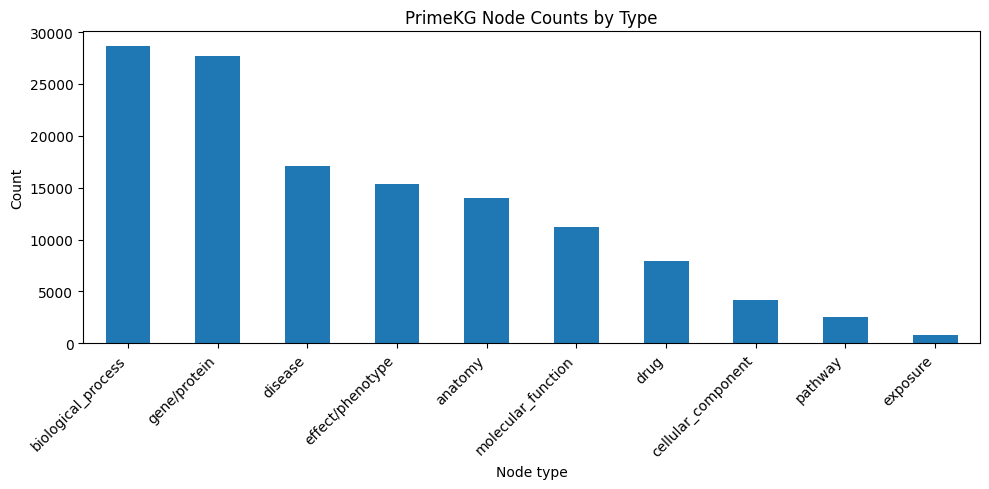

In [7]:
node_type_counts = nodes["node_type"].value_counts().rename_axis("node_type").reset_index(name="count")
node_type_counts["pct"] = (node_type_counts["count"] / node_type_counts["count"].sum() * 100).round(2)

ax = node_type_counts.plot.bar(x="node_type", y="count", legend=False)
ax.set_title("PrimeKG Node Counts by Type")
ax.set_xlabel("Node type")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

node_type_counts

## 8. Node Source Distribution

Summarize the source ontology or database for each node. This is useful for provenance labels and source-specific filters in the visualization interface.

,node_source,count,pct
0,GO,43987,34.00
1,NCBI,27671,21.39
2,MONDO,15813,12.22
3,HPO,15311,11.83
4,UBERON,14035,10.85
5,DrugBank,7957,6.15
6,REACTOME,2516,1.94
7,MONDO_grouped,1267,0.98
8,CTD,818,0.63


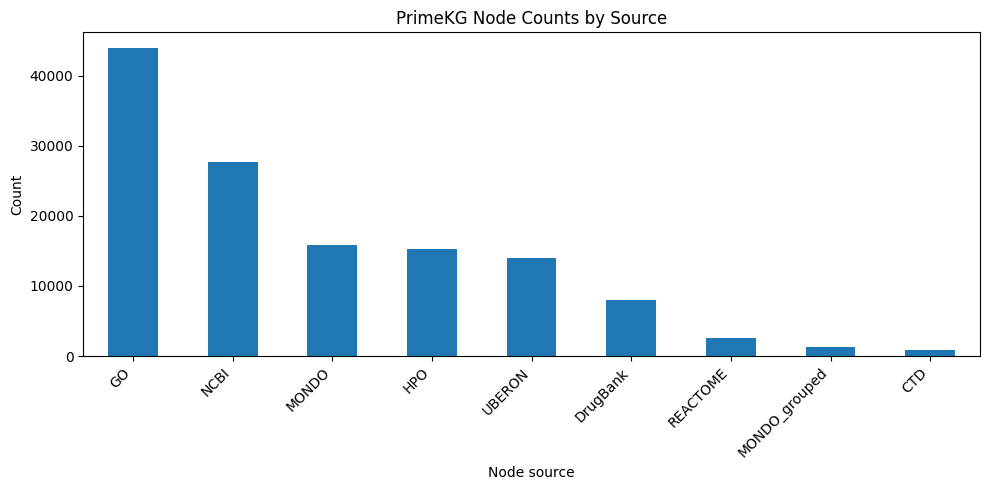

In [8]:
node_source_counts = nodes["node_source"].value_counts().rename_axis("node_source").reset_index(name="count")
node_source_counts["pct"] = (node_source_counts["count"] / node_source_counts["count"].sum() * 100).round(2)

ax = node_source_counts.plot.bar(x="node_source", y="count", legend=False)
ax.set_title("PrimeKG Node Counts by Source")
ax.set_xlabel("Node source")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

node_source_counts

## 9. Stream Edge Relation Counts

`edges.csv` has more than 8 million rows, so this cell processes it in chunks. It counts relation types and display relation labels without loading the full edge list into memory.

In [9]:
EDGE_CHUNKSIZE = 500_000

relation_counter = Counter()
display_relation_counter = Counter()
edge_rows = 0

for chunk in pd.read_csv(DATA_DIR / "edges.csv", chunksize=EDGE_CHUNKSIZE):
    edge_rows += len(chunk)
    relation_counter.update(chunk["relation"].dropna())
    display_relation_counter.update(chunk["display_relation"].dropna())

relation_counts = pd.DataFrame(relation_counter.most_common(), columns=["relation", "count"])
relation_counts["pct"] = (relation_counts["count"] / edge_rows * 100).round(2)

display_relation_counts = pd.DataFrame(display_relation_counter.most_common(), columns=["display_relation", "count"])
display_relation_counts["pct"] = (display_relation_counts["count"] / edge_rows * 100).round(2)

print(f"Total edge rows: {edge_rows:,}")
relation_counts.head(20)

Total edge rows: 8,100,498


,relation,count,pct
0,anatomy_protein_present,3036406,37.48
1,drug_drug,2672628,32.99
2,protein_protein,642150,7.93
3,disease_phenotype_positive,300634,3.71
4,bioprocess_protein,289610,3.58
5,cellcomp_protein,166804,2.06
6,disease_protein,160822,1.99
7,molfunc_protein,139060,1.72
8,drug_effect,129568,1.60
9,bioprocess_bioprocess,105772,1.31


## 10. Relation Distribution Plot

Visualize the most common relation types. The distribution is highly skewed, which has implications for default filters and backend query limits.

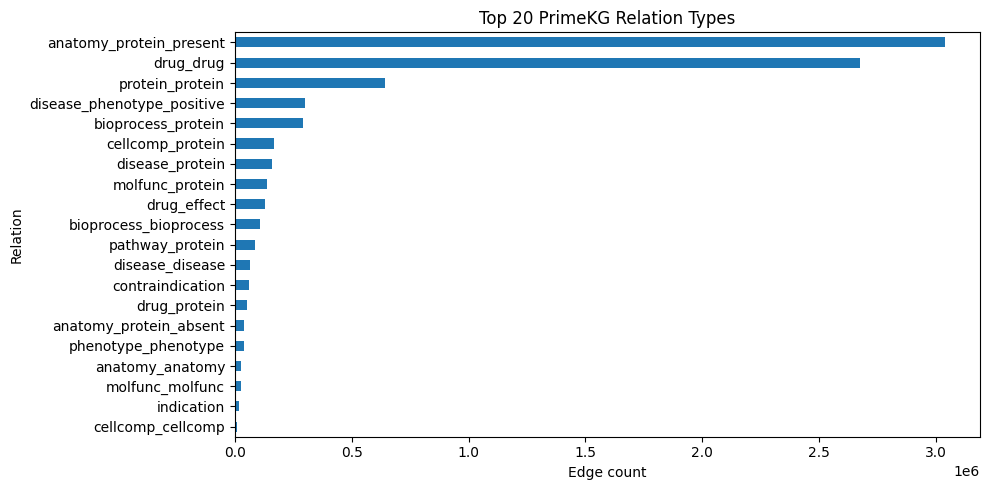

In [10]:
top_n = 20
ax = relation_counts.head(top_n).sort_values("count").plot.barh(x="relation", y="count", legend=False)
ax.set_title(f"Top {top_n} PrimeKG Relation Types")
ax.set_xlabel("Edge count")
ax.set_ylabel("Relation")
plt.tight_layout()

## 11. Display Relation Labels

Inspect the human-readable relation labels. These labels are better candidates for UI text than raw relation identifiers.

In [11]:
display_relation_counts

,display_relation,count,pct
0,expression present,3036406,37.48
1,synergistic interaction,2672628,32.99
2,interacts with,686550,8.48
3,ppi,642150,7.93
4,phenotype present,300634,3.71
5,parent-child,281744,3.48
6,associated with,167482,2.07
7,side effect,129568,1.60
8,contraindication,61350,0.76
9,expression absent,39774,0.49


## 12. Edge Endpoint Type Pairs

Join edge endpoints to node types in a streaming pass. This reveals which node-type combinations are connected by each relation and helps design allowed filter combinations.

In [12]:
node_index_to_type = nodes.set_index("node_index")["node_type"].to_dict()

type_pair_counter = Counter()
missing_endpoint_rows = 0

for chunk in pd.read_csv(DATA_DIR / "edges.csv", chunksize=EDGE_CHUNKSIZE):
    x_type = chunk["x_index"].map(node_index_to_type)
    y_type = chunk["y_index"].map(node_index_to_type)
    missing_endpoint_rows += (x_type.isna() | y_type.isna()).sum()
    type_pair_counter.update(zip(chunk["relation"], x_type, y_type))

type_pair_counts = pd.DataFrame(
    [(relation, x_type, y_type, count) for (relation, x_type, y_type), count in type_pair_counter.items()],
    columns=["relation", "x_type", "y_type", "count"],
).sort_values("count", ascending=False)

print(f"Rows with missing endpoint type: {missing_endpoint_rows:,}")
type_pair_counts.head(30)

Rows with missing endpoint type: 0


,relation,x_type,y_type,count
5,drug_drug,drug,drug,2672628
29,anatomy_protein_present,gene/protein,anatomy,1518203
48,anatomy_protein_present,anatomy,gene/protein,1518203
0,protein_protein,gene/protein,gene/protein,642150
9,disease_phenotype_positive,disease,effect/phenotype,150317
10,disease_phenotype_positive,effect/phenotype,disease,150317
19,bioprocess_protein,gene/protein,biological_process,144805
41,bioprocess_protein,biological_process,gene/protein,144805
14,bioprocess_bioprocess,biological_process,biological_process,105772
40,cellcomp_protein,cellular_component,gene/protein,83402


## 13. Check Edge Symmetry

The README describes `edges.csv` as undirected. This cell checks how many unordered endpoint pairs have both directions represented. It is useful for deciding whether the app should collapse reciprocal rows for display.

In [13]:
edge_pairs = set()
reciprocal_rows = 0
sample_limit = None  # Set to an integer such as 1_000_000 for a faster approximate check.
rows_seen = 0

for chunk in pd.read_csv(DATA_DIR / "edges.csv", usecols=["relation", "x_index", "y_index"], chunksize=EDGE_CHUNKSIZE):
    for relation, x_index, y_index in chunk.itertuples(index=False):
        rows_seen += 1
        if (relation, y_index, x_index) in edge_pairs:
            reciprocal_rows += 1
        edge_pairs.add((relation, x_index, y_index))
    if sample_limit and rows_seen >= sample_limit:
        break

symmetry_summary = pd.Series(
    {
        "rows_checked": rows_seen,
        "unique_directed_relation_pairs": len(edge_pairs),
        "rows_with_previously_seen_reverse": reciprocal_rows,
    }
)

symmetry_summary.to_frame("value")

,value
rows_checked,8100498
unique_directed_relation_pairs,8100128
rows_with_previously_seen_reverse,4050249


## 14. Load Disease Features

Load disease-level text and clinical features. This file can power disease detail panels, search snippets, and text-based summaries.

In [14]:
disease_features = pd.read_csv(DATA_DIR / "disease_features.csv")

print(disease_features.shape)
disease_features.head()

(44133, 18)


,node_index,mondo_id,mondo_name,group_id_bert,group_name_bert,mondo_definition,umls_description,orphanet_definition,orphanet_prevalence,orphanet_epidemiology,orphanet_clinical_description,orphanet_management_and_treatment,mayo_symptoms,mayo_causes,mayo_risk_factors,mayo_complications,mayo_prevention,mayo_see_doc
0,27165,8019,mullerian aplasia and hyperandrogenism,NaN,NaN,"Deficiency of the glycoprotein WNT4, associated with loss of function mutation(s) in the WNT4 gene. The condition in...","Deficiency of the glycoprotein wnt4, associated with loss of function mutation in the wnt4 gene. The condition in 46...","A rare syndrome with 46,XX disorder of sex development characterized by Müllerian duct hypoplasia or agenesis associ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,27165,8019,mullerian aplasia and hyperandrogenism,NaN,NaN,"Deficiency of the glycoprotein WNT4, associated with loss of function mutation(s) in the WNT4 gene. The condition in...","Deficiency of the glycoprotein wnt4, associated with loss of function mutation in the wnt4 gene. The condition in 46...","A rare syndrome with 46,XX disorder of sex development characterized by Müllerian duct hypoplasia or agenesis associ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,27166,11043,"myelodysplasia, immunodeficiency, facial dysmorphism, short stature, and psychomotor delay",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27168,8878,"bone dysplasia, lethal Holmgren type",NaN,NaN,"Bone dysplasia lethal Holmgren type (BDLH) is a lethal bone dysplasia characterized at birth by low birth weight, a ...","A lethal bone dysplasia with characteristics of low birth weight, rhizomelic dwarfism, bent femora and short chest p...","Bone dysplasia lethal Holmgren type (BDLH) is a lethal bone dysplasia characterized at birth by low birth weight, a ...",<1/1000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,27169,8905,predisposition to invasive fungal disease due to CARD9 deficiency,NaN,NaN,NaN,NaN,"A rare, genetic primary immunodeficiency characterized by increased susceptibility to fungal infections, typically m...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 15. Disease Feature Completeness

Measure non-null coverage for each disease feature column. Sparse fields should be handled carefully in the UI, while high-coverage fields are good candidates for default display.

In [15]:
disease_feature_coverage = pd.DataFrame(
    {
        "column": disease_features.columns,
        "non_null": disease_features.notna().sum().values,
        "non_null_pct": (disease_features.notna().mean().values * 100).round(2),
    }
).sort_values("non_null_pct", ascending=False)

disease_feature_coverage

,column,non_null,non_null_pct
0,node_index,44133,100.00
1,mondo_id,44133,100.00
2,mondo_name,44133,100.00
5,mondo_definition,35454,80.33
6,umls_description,29968,67.90
12,mayo_symptoms,15346,34.77
13,mayo_causes,15321,34.72
7,orphanet_definition,15234,34.52
14,mayo_risk_factors,14712,33.34
17,mayo_see_doc,13678,30.99


## 16. Load Drug Features

Load drug-level descriptive and pharmacological attributes. These fields can support drug detail panels, faceted search, and tooltip content.

In [16]:
drug_features = pd.read_csv(DATA_DIR / "drug_features.csv")

print(drug_features.shape)
drug_features.head()

(7957, 18)


,node_index,description,half_life,indication,mechanism_of_action,protein_binding,pharmacodynamics,state,atc_1,atc_2,atc_3,atc_4,category,group,pathway,molecular_weight,tpsa,clogp
0,14012,Copper is a transition metal and a trace element in the body. It is important to the function of many enzymes includ...,NaN,For use in the supplementation of total parenteral nutrition and in contraception with intrauterine devices.,Copper is absorbed from the gut via high affinity copper uptake protein and likely through low affinity copper uptak...,"Copper is nearly entirely bound by ceruloplasmin (65-90%), plasma albumin (18%), and alpha 2-macroglobulin (12%).",Copper is incorporated into many enzymes throughout the body as an essential part of their function. Copper ions are...,Copper is a solid.,NaN,NaN,NaN,NaN,Copper is part of Copper-containing Intrauterine Device ; Decreased Embryonic Implantation ; Decreased Sperm Motilit...,Copper is approved and investigational.,NaN,NaN,NaN,NaN
1,14013,"Oxygen is an element displayed by the symbol O, and atomic number 8. It is an essential element for human survival. ...",The half-life is approximately 122.24 seconds,"Oxygen therapy in clinical settings is used across diverse specialties, including various types of anoxia, hypoxia o...",Oxygen therapy increases the arterial pressure of oxygen and is effective in improving gas exchange and oxygen deliv...,Oxygen binds to oxygen-carrying protein in red blood cells called hemoglobin with high affinity. The amount of oxyge...,"Oxygen therapy improves effective cellular oxygenation, even at a low rate of tissue perfusion. Oxygen molecules adj...",Oxygen is a gas.,Oxygen is anatomically related to various.,Oxygen is in the therapeutic group of all other therapeutic products.,Oxygen is pharmacologically related to all other therapeutic products.,The chemical and functional group of is medical gases.,Oxygen is part of Chalcogens ; Elements ; Gases ; Medical Gases ; Miscellaneous Therapeutic Agents ; Other Miscellan...,Oxygen is approved and vet_approved.,NaN,The molecular weight is 32.0.,Oxygen has a topological polar surface area of 34.14.,NaN
2,14014,"Flunisolide (marketed as AeroBid, Nasalide, Nasarel) is a corticosteroid with anti-inflammatory actions. It is often...",The half-life is 1.8 hours,For the maintenance treatment of asthma as a prophylactic therapy.,Flunisolide is a glucocorticoid receptor agonist. The antiinflammatory actions of corticosteroids are thought to inv...,Approximately 40% after oral inhalation,Flunisolide is a synthetic corticosteroid. It is administered either as an oral metered-dose inhaler for the treatme...,Flunisolide is a solid.,Flunisolide is anatomically related to respiratory system and respiratory system.,Flunisolide is in the therapeutic group of nasal preparations and drugs for obstructive airway diseases.,Flunisolide is pharmacologically related to decongestants and other nasal preparations for topical use and other dru...,The chemical and functional group of is corticosteroids and glucocorticoids.,Flunisolide is part of Adrenal Cortex Hormones ; Adrenals ; Agents to Treat Airway Disease ; Anti-Asthmatic Agents ;...,Flunisolide is approved and investigational.,NaN,The molecular weight is 434.5.,Flunisolide has a topological polar surface area of 93.06.,The log p value of is 2.41.
3,14015,"Alclometasone is synthetic glucocorticoid steroid for topical use in dermatology as anti-inflammatory, antipruritic,...",NaN,For the relief of the inflammatory and pruritic manifestations of corticosteroid-responsive dermatoses.,"The mechanism of the anti-inflammatory activity of the topical steroids, in general, is unclear. However, corticoste...",NaN,Alclometasone is a synthetic corticosteroid for topical dermatologic use. The corticosteroids constitute a class of ...,Alclometasone is a solid.,Alclometasone is anatomically related to dermatologicals and sensory organs.,"Alclometasone is in the therapeutic group of corticosteroids,

## 17. Drug Feature Completeness

Measure non-null coverage for drug feature columns. This helps identify which drug attributes are consistently available enough for primary UI placement.

In [17]:
drug_feature_coverage = pd.DataFrame(
    {
        "column": drug_features.columns,
        "non_null": drug_features.notna().sum().values,
        "non_null_pct": (drug_features.notna().mean().values * 100).round(2),
    }
).sort_values("non_null_pct", ascending=False)

drug_feature_coverage

,column,non_null,non_null_pct
0,node_index,7957,100.00
13,group,7957,100.00
7,state,6517,81.90
12,category,5431,68.25
1,description,4591,57.70
3,indication,3393,42.64
4,mechanism_of_action,3242,40.74
11,atc_4,2818,35.42
10,atc_3,2818,35.42
9,atc_2,2818,35.42


## 18. Disease Grouping Files

Inspect grouped disease files. Disease grouping can reduce visual clutter by collapsing many fine-grained MONDO disease nodes into higher-level disease groups.

In [18]:
grouped_diseases = pd.read_csv(DATA_DIR / "kg_grouped_diseases.csv")
bert_group_map = pd.read_csv(DATA_DIR / "kg_grouped_diseases_bert_map.csv")

print("kg_grouped_diseases:", grouped_diseases.shape)
print("kg_grouped_diseases_bert_map:", bert_group_map.shape)

grouped_diseases.head()

kg_grouped_diseases: (22205, 6)
kg_grouped_diseases_bert_map: (6392, 7)


,node_id,node_type,node_name,node_source,group_name_auto,group_name_bert
0,13924,disease,osteogenesis imperfecta type 13,MONDO,osteogenesis imperfecta,osteogenesis imperfecta
1,11160,disease,autosomal recessive nonsyndromic deafness 15,MONDO,autosomal recessive nonsyndromic deafness,autosomal recessive nonsyndromic deafness
2,8099,disease,congenital stationary night blindness autosomal dominant 2,MONDO,congenital stationary night blindness autosomal dominant,congenital stationary night blindness autosomal dominant
3,14854,disease,autosomal dominant nonsyndromic deafness 66,MONDO,autosomal dominant nonsyndromic deafness,autosomal dominant nonsyndromic deafness
4,33202,disease,"deafness, autosomal recessive 109",MONDO,"deafness, autosomal recessive","deafness, autosomal recessive"


## 19. Disease Group Size Distribution

Summarize the size of BERT-derived disease groups. Large groups may be useful aggregate nodes; singleton or small groups may be better left as individual diseases.

,group_name_bert,disease_count
0,developmental and epileptic encephalopathy,87
1,retinitis pigmentosa,81
2,autosomal recessive nonsyndromic deafness,80
3,Charcot-Marie-Tooth disease,74
4,hereditary spastic paraplegia,62
5,autosomal dominant nonsyndromic deafness,54
6,spermatogenic failure,51
7,"intellectual disability, autosomal recessive",48
8,cataract,46
9,spinocerebellar ataxia,44


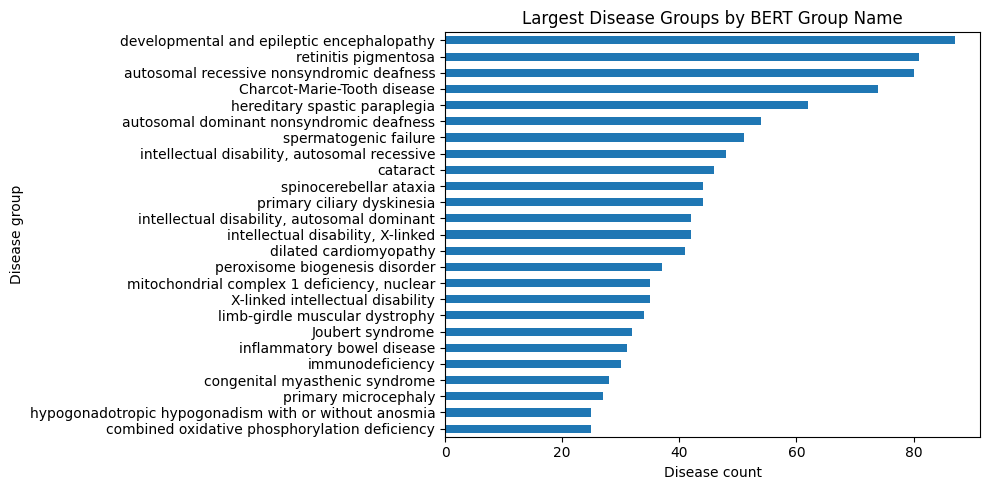

In [19]:
group_size_counts = (
    grouped_diseases.dropna(subset=["group_name_bert"])
    .groupby("group_name_bert")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="disease_count")
)

ax = group_size_counts.head(25).sort_values("disease_count").plot.barh(
    x="group_name_bert", y="disease_count", legend=False
)
ax.set_title("Largest Disease Groups by BERT Group Name")
ax.set_xlabel("Disease count")
ax.set_ylabel("Disease group")
plt.tight_layout()

group_size_counts.head(25)

## 20. Search Nodes by Name

Define a small helper for searching nodes by case-insensitive name substring. This is a useful starting point for choosing interesting seed nodes for graph exploration.

In [20]:
def search_nodes(query, node_type=None, limit=20):
    mask = nodes["node_name"].str.contains(query, case=False, na=False)
    if node_type is not None:
        mask &= nodes["node_type"].eq(node_type)
    return nodes.loc[mask].head(limit)

search_nodes("diabetes")

,node_index,node_id,node_type,node_name,node_source
22493,22493,831,effect/phenotype,Insulin-resistant diabetes mellitus,HPO
24491,24491,5978,effect/phenotype,Type II diabetes mellitus,HPO
24974,24974,873,effect/phenotype,Diabetes insipidus,HPO
27346,27346,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped
27653,27653,100164_16391,disease,permanent neonatal diabetes mellitus,MONDO_grouped
27654,27654,20525_12522_30089_30088_11073_12480_30087_100165,disease,neonatal diabetes mellitus,MONDO_grouped
27724,27724,18495,disease,X-linked intellectual disability-limb spasticity-retinal dystrophy-diabetes insipidus syndrome,MONDO
28208,28208,5148,disease,type 2 diabetes mellitus,MONDO
28294,28294,7450,disease,neurohypophyseal diabetes insipidus,MONDO
28488,28488,9099,disease,nephrogenic diabetes insipidus-intracranial calcification syndrome,MONDO


## 21. Extract a One-Hop Neighborhood

Define a chunked helper that retrieves a one-hop neighborhood around a selected `node_index`. This mirrors the kind of backend query needed for an interactive graph viewer.

In [21]:
def one_hop_edges(seed_node_index, relation_filter=None, max_edges=2_000):
    matches = []
    usecols = ["relation", "display_relation", "x_index", "y_index"]

    for chunk in pd.read_csv(DATA_DIR / "edges.csv", usecols=usecols, chunksize=EDGE_CHUNKSIZE):
        mask = chunk["x_index"].eq(seed_node_index) | chunk["y_index"].eq(seed_node_index)
        if relation_filter is not None:
            allowed = {relation_filter} if isinstance(relation_filter, str) else set(relation_filter)
            mask &= chunk["relation"].isin(allowed)

        found = chunk.loc[mask]
        if not found.empty:
            matches.append(found)

        if sum(len(frame) for frame in matches) >= max_edges:
            break

    if not matches:
        return pd.DataFrame(columns=usecols)

    result = pd.concat(matches, ignore_index=True).head(max_edges)
    return result

# Example: replace this with a node_index from search_nodes(...) above.
example_seed = int(search_nodes("diabetes", node_type="disease").iloc[0]["node_index"])
example_edges = one_hop_edges(example_seed, max_edges=100)
example_edges.head()

,relation,display_relation,x_index,y_index
0,disease_phenotype_negative,phenotype absent,27346,26194
1,disease_phenotype_negative,phenotype absent,27346,85012
2,disease_phenotype_negative,phenotype absent,27346,23296
3,disease_phenotype_positive,phenotype present,27346,85561
4,disease_phenotype_positive,phenotype present,27346,25526


## 22. Enrich Neighborhood Edges with Node Metadata

Join one-hop edges back to node metadata so the neighborhood is readable. This output shape is close to what an API endpoint could return to a frontend visualization.

In [22]:
def enrich_edges(edge_df):
    x_nodes = nodes.add_prefix("x_").rename(columns={"x_node_index": "x_index"})
    y_nodes = nodes.add_prefix("y_").rename(columns={"y_node_index": "y_index"})
    return edge_df.merge(x_nodes, on="x_index", how="left").merge(y_nodes, on="y_index", how="left")

enriched_example_edges = enrich_edges(example_edges)
enriched_example_edges.head(20)

,relation,display_relation,x_index,y_index,x_node_id,x_node_type,x_node_name,x_node_source,y_node_id,y_node_type,y_node_name,y_node_source
0,disease_phenotype_negative,phenotype absent,27346,26194,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,45081,effect/phenotype,Abnormality of body mass index,HPO
1,disease_phenotype_negative,phenotype absent,27346,85012,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,1953,effect/phenotype,Diabetic ketoacidosis,HPO
2,disease_phenotype_negative,phenotype absent,27346,23296,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,30057,effect/phenotype,Autoimmune antibody positivity,HPO
3,disease_phenotype_positive,phenotype present,27346,85561,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,3593,effect/phenotype,Infantile onset,HPO
4,disease_phenotype_positive,phenotype present,27346,25526,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,3074,effect/phenotype,Hyperglycemia,HPO
5,disease_phenotype_positive,phenotype present,27346,24491,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,5978,effect/phenotype,Type II diabetes mellitus,HPO
6,disease_phenotype_positive,phenotype present,27346,22759,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,6,effect/phenotype,Autosomal dominant inheritance,HPO
7,disease_phenotype_positive,phenotype present,27346,84359,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,9800,effect/phenotype,Maternal diabetes,HPO
8,disease_phenotype_positive,phenotype present,27346,22577,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,31284,effect/phenotype,Flushing,HPO
9,disease_phenotype_positive,phenotype present,27346,24608,14589_18911_10894_11668_12818_7452_13240_12348_12513_13242_7453_14674_11667,disease,maturity-onset diabetes of the young,MONDO_grouped,1511,effect/phenotype,Intrauterine growth retardation,HPO


## 23. Neighborhood Node Type Mix

Summarize the entity types found in a seed node's one-hop neighborhood. This can inform default colors, legends, and neighbor prioritization in the visualization.

In [23]:
def neighborhood_node_type_mix(edge_df, seed_node_index):
    if edge_df.empty:
        return pd.DataFrame(columns=["node_type", "count"])

    neighbor_indices = pd.concat(
        [
            edge_df.loc[edge_df["x_index"].eq(seed_node_index), "y_index"],
            edge_df.loc[edge_df["y_index"].eq(seed_node_index), "x_index"],
        ]
    )
    neighbor_nodes = nodes[nodes["node_index"].isin(neighbor_indices)]
    return neighbor_nodes["node_type"].value_counts().rename_axis("node_type").reset_index(name="count")

neighborhood_node_type_mix(example_edges, example_seed)

,node_type,count
0,effect/phenotype,30
1,gene/protein,14
2,disease,3


## 24. Initial Visualization Design Notes

Use the observations from this EDA to capture early product and engineering implications for BioKG Explorer.

In [24]:
design_notes = pd.DataFrame(
    [
        {
            "observation": "The graph has millions of edges and several highly dominant relation types.",
            "implication": "Do not render the full graph in the browser; use backend-filtered subgraphs and pagination/limits.",
        },
        {
            "observation": "Disease, drug, and gene/protein nodes have rich biomedical value for users.",
            "implication": "Start with disease-centered search and one-hop expansion across drugs, genes, phenotypes, and pathways.",
        },
        {
            "observation": "Feature tables contain long text fields with uneven coverage.",
            "implication": "Use feature panels with graceful handling for missing fields instead of dense graph labels.",
        },
        {
            "observation": "Disease grouping files are available.",
            "implication": "Offer grouped disease exploration or aggregate views to reduce visual clutter.",
        },
    ]
)

design_notes

,observation,implication
0,The graph has millions of edges and several highly dominant relation types.,Do not render the full graph in the browser; use backend-filtered subgraphs and pagination/limits.
1,"Disease, drug, and gene/protein nodes have rich biomedical value for users.","Start with disease-centered search and one-hop expansion across drugs, genes, phenotypes, and pathways."
2,Feature tables contain long text fields with uneven coverage.,Use feature panels with graceful handling for missing fields instead of dense graph labels.
3,Disease grouping files are available.,Offer grouped disease exploration or aggregate views to reduce visual clutter.
